# 🐼 Pandas Series Masterclass

**The Foundation of Data Analysis & Machine Learning**

Welcome to the most comprehensive, practice-oriented guide to Pandas Series. 
This notebook is structured to build your intuition, show you real-world applications, and test your knowledge immediately after every concept.


In [89]:
# ==========================================
# 🛠️ SETUP & MOCK DATA GENERATION
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import io

print(f"🐼 Pandas Version: {pd.__version__}")

# Creating mock CSV data so this notebook runs standalone without external files

csv_subs = pd.read_csv(r"D:\Projects\personalNotes\assets\pandas\subs.csv")

csv_kohli = pd.read_csv(r"D:\Projects\personalNotes\assets\pandas\kohli_ipl.csv")

# Step 1: usecols tells pandas to ONLY load the "movies" column and the "rating" column.
# Step 2: index_col sets "movies" as the index.
# Step 3: Now that only ONE column of data remains ("rating"), .squeeze("columns") will work perfectly.

csv_movies = pd.read_csv(
    r"D:\Projects\personalNotes\assets\pandas\bollywood.csv", 
    usecols=["movie", "lead"], # <-- Add this (replace "rating" with your actual column name)
    index_col="movie"
).squeeze("columns")

print(csv_subs.head(), csv_kohli.head(), csv_movies.head(), sep="\n\n\n")

🐼 Pandas Version: 3.0.3
   Subscribers gained
0                  48
1                  57
2                  40
3                  43
4                  44


   match_no  runs
0         1     1
1         2    23
2         3    13
3         4    12
4         5     1


movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
Name: lead, dtype: str


# 🧠 What is Pandas and Series?

**Pandas** is a fast, powerful, flexible, and easy-to-use open-source data analysis tool built on top of Python. 
A **Pandas Series** is a **1-Dimensional labeled array** capable of holding any data type (integers, strings, floats, etc.). It is essentially a single column in a table.

## 💡 Mental Model
Think of a Python List as a row of lockers numbered `0, 1, 2...`. You can only find items by their locker number. 
Think of a Pandas Series as a row of **named lockers** (e.g., "Maths", "Science"). You can find items by their name OR their number. The "name" is called the **Index**.

```text
┌─────────────────────┐      ┌─────────────────────┐
│   Python List       │      │   Pandas Series     │
├──────────┬──────────┤      ├──────────┬──────────┤
│ Index    │ Value    │      │ Index    │ Value    │
├──────────┼──────────┤      ├──────────┼──────────┤
│ 0        │ 67       │      │ maths    │ 67       │
│ 1        │ 57       │  =>  │ english  │ 57       │
│ 2        │ 89       │      │ science  │ 89       │
└──────────┴──────────┘      └──────────┴──────────┘
  (Default Numbers)            (Custom Labels)
```
## 🌍 Real-World Use Case
Tracking daily stock prices. The **Index** is the Date, and the **Value** is the Stock Price. This allows you to instantly ask: "What was the price on Oct 5th?" without counting array positions.

## ⚠️ Common Mistakes
Confusing a Series with a Python List. Lists don't support vectorized math (e.g., `list * 2` duplicates the list, but `Series * 2` multiplies every element by 2).

## 🎤 Interview Questions
**Q: What is the difference between a Pandas Series and a NumPy array?**
> **A:** Both are backed by NumPy arrays under the hood, but a Series has an **Index** (labels) and can hold mixed data types, whereas a NumPy array is strictly homogeneous and only has integer positions.

**Q: Why use a Pandas Series instead of a standard Python dictionary?**
> **A:** While both map keys to values, a Pandas Series is backed by NumPy arrays. This means it supports vectorized mathematical operations, broadcasting, and boolean indexing—all of which are impossible or extremely slow with standard Python dictionaries.



In [2]:
# --- 1. SERIES FROM A BASIC LIST (STRINGS) ---
country = ["India", "Pakistan", "Sri Lanka", "China", "USA", "UK"]

# pd.Series() converts the standard Python list into a 1D Pandas Series.
# Because no index is provided, Pandas automatically assigns an integer index starting from 0.
print(pd.Series(country))

0        India
1     Pakistan
2    Sri Lanka
3        China
4          USA
5           UK
dtype: str


In [3]:
# --- 2. SERIES FROM A BASIC LIST (INTEGERS) ---
runs = [13, 24, 56, 100]

# Exactly the same behavior as above, but Pandas will automatically 
# detect the data type (dtype) as int64 rather than object (string).
print(pd.Series(runs))

0     13
1     24
2     56
3    100
dtype: int64


In [4]:
# --- 3. SERIES WITH A CUSTOM INDEX ---
marks = [55, 75, 85, 89, 100]
subjects = ["Maths", "English", "Science", "Social Science", "Hindi"]

# We use the 'index' argument to map the 'subjects' list to the 'marks' list. 
# Now, instead of looking up a score by row 0 or 1, you can look it up by "Maths" or "English".
print(pd.Series(marks, index=subjects), "\n\n")

# The 'name' argument attaches a metadata label to the entire Series.
print(pd.Series(marks, index=subjects, name="Anuj's Score"))

Maths              55
English            75
Science            85
Social Science     89
Hindi             100
dtype: int64 


Maths              55
English            75
Science            85
Social Science     89
Hindi             100
Name: Anuj's Score, dtype: int64


## 🎯 Practice Tasks

🟢 **Easy:** Create a Series of 5 country names.

🟡 **Medium:** Create a Series of 4 marks with custom subject names as the index.

🔴 **Hard:** Create a Series, then extract the underlying NumPy array using an attribute.


In [5]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
# Creating a basic Series
countries = ['India', 'USA', 'UK', 'Nepal', 'Srilanka']
s_countries = pd.Series(countries)
print("--- Basic Series ---")
print(s_countries)

--- Basic Series ---
0       India
1         USA
2          UK
3       Nepal
4    Srilanka
dtype: str


In [6]:
# Creating a Series with a custom index
marks = [67, 57, 89, 100]
subjects = ['maths', 'english', 'science', 'hindi']
s_marks = pd.Series(marks, index=subjects, name='Student Marks')
print("\n--- Series with Custom Index ---")
print(s_marks)



--- Series with Custom Index ---
maths       67
english     57
science     89
hindi      100
Name: Student Marks, dtype: int64


In [7]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 1)
# ==========================================
# 🟢 Easy: Create a Series of 5 country names.
# YOUR CODE HERE:


# 🟡 Medium: Create a Series of 4 marks with custom subject names as the index.
# YOUR CODE HERE:


# 🔴 Hard: Create a Series, then extract the underlying NumPy array using an attribute.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 1)
# ==========================================
# 🟢 Easy
print(pd.Series(['India', 'USA', 'UK', 'Nepal', 'Srilanka']))

# 🟡 Medium
print(pd.Series([67, 57, 89, 100], index=['maths', 'english', 'science', 'hindi']))

# 🔴 Hard
s = pd.Series([1, 2, 3])
print(s.values) # or s.to_numpy()

```

</details>

# 🧠 Creating Series (Dicts & CSV)

You can create a Series from various data structures, mainly **Lists** and **Dictionary** or directly from a **CSV file**. 

**💡 Fun Fact**: When you create a Series from a Python dictionary, the dictionary keys automatically become the Series index, and the dictionary values become the Series values!

## 💡 Mental Model
A dictionary is already a mapping of `Key -> Value`. Pandas just renames `Key` to `Index`. It's a seamless translation.

## 📊 Visual Diagram
```text
┌─────────────────────┐      ┌─────────────────────┐
│   Python Dictionary │      │   Pandas Series     │
├──────────┬──────────┤      ├──────────┬──────────┤
│ Key      │ Value    │      │ Index    │ Values   │
├──────────┼──────────┤      ├──────────┼──────────┤
│ 'maths'  │ 67       │      │ maths    │ 67       │
│ 'eng'    │ 57       │  =>  │ eng      │ 57       │
└──────────┴──────────┘      └──────────┴──────────┘
```
## Reading Data from CSV (As a Series)

In the real world, you load data from files. `pd.read_csv()` normally loads data as a 2D DataFrame. To force it into a 1D Series, use `squeeze=True` (or `.squeeze("columns")` in newer Pandas versions).

(Note: We will use `io.StringIO` to simulate reading a CSV file so this notebook runs perfectly without needing you to download any external files!)

## 🌍 Real-World Use Case
Loading a massive CSV file (e.g., 10GB) but you only need **one specific column** (like `user_id`). Using `read_csv` with `squeeze` loads only that column into memory as a 1D Series, saving massive amounts of RAM.

## ⚠️ Common Mistakes
**Pandas 2.0+ Deprecation:** Older tutorials use `pd.read_csv(file, squeeze=True)`. In modern Pandas, `squeeze=True` is removed. You must now use `pd.read_csv(file).squeeze("columns")`.

## 🎤 Interview Questions
**Q: What happens if you pass a dictionary to `pd.Series()` but also provide an `index` list that contains a key NOT in the dictionary?**
> **A:** Pandas will insert `NaN` (Not a Number / Missing Value) for that missing key. It aligns data based on labels!

In [8]:
# --- SERIES USING A DICTIONARY ---
marks = [55, 75, 85, 89, 100]
subjects = ["Maths", "English", "Science", "Social Science", "Hindi"]

# First, we combine the two parallel lists into a single dictionary using zip().
# Keys become the subjects, values become the marks.
my_dictionary = dict(zip(subjects, marks))
print(my_dictionary)

# When you pass a dictionary to a Series, Pandas is smart enough to automatically 
# use the dictionary keys as the Index and the dictionary values as the data points.
marksDict = pd.Series(my_dictionary, name="Anuj's Marks")
print(marksDict)

{'Maths': 55, 'English': 75, 'Science': 85, 'Social Science': 89, 'Hindi': 100}
Maths              55
English            75
Science            85
Social Science     89
Hindi             100
Name: Anuj's Marks, dtype: int64


## 🎯 Practice Tasks

🟢 **Easy:** Create a Series from a dictionary of 3 fruits and their prices.

🟡 **Medium:** Read the mock `csv_kohli` data (provided in setup) as a Series, using `match_no` as the index.

🔴 **Hard:** Create a Series from a dict, but pass an `index` parameter that is missing one key. Observe the output.


In [9]:
# 1. We start with 'csv_kohli', which is a 2D DataFrame containing at least two columns: 
#    one called 'match_no' and one containing the runs.

# 2. .set_index('match_no') moves the 'match_no' column out of the data area 
#    and turns it into the official row labels (the Index).

# 3. .squeeze("columns") looks at the remaining DataFrame. Since there is only 
#    one column of data left (the runs), it "squeezes" the 2D DataFrame down into a 1D Series.

vk_runs = csv_kohli.set_index('match_no').squeeze("columns")

print("\n--- From CSV (Kohli Runs) ---")
print(vk_runs)


--- From CSV (Kohli Runs) ---
match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


In [10]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 2)
# ==========================================
# 🟢 Easy: Create a Series from a dictionary of 3 fruits and their prices.
# YOUR CODE HERE:


# 🟡 Medium: Read the mock `csv_subs` data as a Series, using 'date' as the index.
# YOUR CODE HERE:


# 🔴 Hard: Create a Series from {'a': 1, 'b': 2}, but pass index=['a', 'b', 'c']. Print it.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 2)
# ==========================================
# 🟢 Easy
print(pd.Series({'apple': 1.2, 'banana': 0.5, 'orange': 0.8}))

# 🟡 Medium
subs = pd.read_csv(io.StringIO(csv_subs), index_col='date').squeeze("columns")
print(subs)

# 🔴 Hard
s = pd.Series({'a': 1, 'b': 2}, index=['a', 'b', 'c'])
print(s) # Notice 'c' gets NaN!

```

</details>

## 🧠 Attributes & Exploratory Methods

**Attributes** (no parentheses) give you metadata about the Series. **Methods** (with parentheses) perform actions like viewing data (`head`, `tail`, `sample`), counting frequencies (`value_counts`), or sorting.
- `size`: To instantly know how many data points you are working with.
- `dtype`: The data type of the elements. Pandas behaves differently depending on the data type. You cannot do math on strings (object), and you cannot do text manipulation on numbers (int64 or float64).
- `name`: The name of the Series. It tells you what the entire column of data represents.
- `is_unique`: Returns True if there are no duplicate values.
- `index`: Returns the index labels.It reveals how your data is labeled and how you can access it.
- `values`: Returns the actual data as a NumPy array.

Methods are actions performed on the Series (they require parentheses ()).
- `head(n)`/`tail(n)`: View the first/last 'n' rows.
- `sample(n)`: Grabs 'n' random rows. Great for checking if data loaded correctly.
- `value_counts()`: Crucial. Counts the frequency of every unique value.
- `sort_values()`: Sorts the data by the values.
- `sort_index()`: Sorts the data by the index labels

## 💡 Mental Model
Attributes are like checking the ID card of your data (How big is it? What type is it?). Methods are like asking your data to do tricks (Show me the top 5! Sort yourself!).

## 📊 Visual Diagram
```text
┌──────────────────────────────────────────────┐
│ Series: [10, 20, 20, 30]                     │
├──────────────────────────────────────────────┤
│ Attributes (Facts):                          │
│ • size: 4                                    │
│ • dtype: int64                               │
│ • is_unique: False (20 is repeated)          │
├──────────────────────────────────────────────┤
│ Methods (Actions):                           │
│ • value_counts(): 20->2, 10->1, 30->1        │
│ • sort_values(ascending=False): 30, 20, 20...│
└──────────────────────────────────────────────┘
```

## 🌍 Real-World Use Case
You have a Series of 10,000 customer IDs. You use `is_unique` to check if there are duplicate accounts. You use `value_counts()` to find out which product category is bought the most.

## ⚠️ Common Mistakes
Forgetting that `sort_values()` returns a **new** Series. If you want to permanently change the original, you must use `inplace=True` or reassign it: `s = s.sort_values()`.

## 🎤 Interview Questions
**Q: What is the difference between `sort_values()` and `sort_index()`?**
> **A:** `sort_values()` orders the data by the actual numbers/strings (the values). `sort_index()` orders the data alphabetically/numerically by the labels on the left (the index).

**Q: What does the `inplace=True` parameter do?**
> **A:** By default, Pandas methods return a copy of the modified data. If you set `inplace=True`, it alters the original Series directly in memory and returns None.


In [11]:
# 1. SIZE: Returns the total number of elements in the Series.
print(vk_runs.size)

# Use this when you need to verify that a dataset has fully loaded without missing rows, or when you are calculating averages manually and need the total count. (Note: Unlike the len() function, size will count NaN or missing values).

215


In [12]:
# 2. DTYPE: Returns the data type of the underlying data (e.g., int64, float64, object).
print(vk_runs.dtype)

# Use this immediately after importing data from a CSV or Excel file to ensure Pandas interpreted your numbers as numbers and your text as text. It is your first step in debugging if a mathematical operation throws an error.

int64


In [13]:
# 3. NAME: Returns the name assigned to the Series, if any.
print(vk_runs.name)

# Use this when you are working with multiple standalone Series and are preparing to combine them into a single 2D DataFrame. The name of the Series will automatically become the column header in the new DataFrame.

runs


In [14]:
# 4. IS_UNIQUE: Returns a boolean (True/False) checking if all values are strictly unique.
print(vk_runs.is_unique)

# Use this when you have a column that is supposed to act as a primary key or unique identifier (like Student IDs, Social Security Numbers, or Email Addresses) to quickly verify that no duplicates snuck into your dataset.

False


In [15]:
# 5. INDEX: Returns the index labels (the row names or row numbers) of the Series.
print(vk_runs.index)

# Use this when you need to extract a list of all your labels (e.g., getting a list of all the subject names in your marks Series) or when you need to check if a specific label exists in your dataset before trying to search for it.

RangeIndex(start=1, stop=216, step=1, name='match_no')


In [16]:
# 6. VALUES: Returns only the data points as a raw 1D NumPy array, stripping away the index.
print(vk_runs.values)

# When to use it: Use this when you are passing your data into external machine learning libraries (like Scikit-Learn) or advanced mathematical functions (in NumPy) that do not understand Pandas objects and strictly require a raw, unlabelled array of numbers.

[  1  23  13  12   1   9  34   0  21   3  10  38   3  11  50   2  22  19
  16  15  20  38  19  24   7   2  16  17  24  38  34  42  13  58   3  14
  37   9  23  12  71  35  30  56  67  27  27  39  15  11  31  70   8  35
   8   6  57  22  16   4  16  18  45   9  36   9   3  73  42  24  51  35
  58  65   1  11   1  32  25  57  93  99  17  14  56  49   0  31  21   4
   0  35   0   4  10  27  67  38  73  13  41  18  51  62  35   1  34  48
  32  82  19  44   1  12  12  75  79  33  80 100  14  52 108  20   7 109
  75 113  54   0  54  62  28  64   0  10  55  20   6   5  58  31  21  57
  92  30  18  68  32   8  39  70  48  12   4   6  46   3  23  84  41  67
   8 100   9  13  23  25  16  18   9   7  29   1  72  43  43  90  48  14
  33  50   8   6  33  33   5  72   8  12  35   5  25   5   4  25  51  53
  39  41  12   5  48   1  12   0   0   9  58  30   0  20  73  25   7]


In [17]:
# 1. .head() grabs the first 5 rows by default.
# 2. .tail(3) grabs exactly the last 3 rows.
# By putting them in the same print() function separated by a comma, 
# Python will print the top of the movies data, followed by the bottom of the runs data.
print(csv_movies.head(), vk_runs.tail(3))

                                title_x    imdb_id  \
0              Uri: The Surgical Strike  tt8291224   
1                         Battalion 609  tt9472208   
2  The Accidental Prime Minister (film)  tt6986710   
3                       Why Cheat India  tt8108208   
4                       Evening Shadows  tt6028796   

                                         poster_path  \
0  https://upload.wikimedia.org/wikipedia/en/thum...   
1                                                NaN   
2  https://upload.wikimedia.org/wikipedia/en/thum...   
3  https://upload.wikimedia.org/wikipedia/en/thum...   
4                                                NaN   

                                           wiki_link  \
0  https://en.wikipedia.org/wiki/Uri:_The_Surgica...   
1        https://en.wikipedia.org/wiki/Battalion_609   
2  https://en.wikipedia.org/wiki/The_Accidental_P...   
3      https://en.wikipedia.org/wiki/Why_Cheat_India   
4      https://en.wikipedia.org/wiki/Evening_Shadows   

 

In [18]:
# .sample() grabs a single, completely random row from the dataset.
print(csv_movies.sample())

# When to use it: Use this when you are applying a new function or transformation to a massive dataset and want to check random spots to ensure your math or text-formatting worked correctly across the entire board, not just at the top.

    title_x    imdb_id                                        poster_path  \
114  Race 3  tt7431594  https://upload.wikimedia.org/wikipedia/en/thum...   

                                wiki_link title_y original_title  is_adult  \
114  https://en.wikipedia.org/wiki/Race_3  Race 3         Race 3         0   

     year_of_release runtime           genres  imdb_rating  imdb_votes  \
114             2018     160  Action|Thriller          2.0       30038   

                                                 story  \
114  Text: 25 years ago arms dealer Shamsher Singh ...   

                                               summary tagline  \
114  Relationships and loyalties of a criminal fami...     NaN   

                                                actors       wins_nominations  \
114  Anil Kapoor|Salman Khan|Bobby Deol|Jacqueline ...  2 wins & 1 nomination   

           release_date  
114  15 June 2018 (USA)  


In [19]:
# If you run value_counts() on an entire DataFrame...
# It will count how many times exact, identical rows appear in the dataset.
# This is useful for finding duplicate rows, but usually not what you want.
print(csv_movies.value_counts())

title_x                  imdb_id     poster_path                                                                                                                     wiki_link                                              title_y                           original_title                    is_adult  year_of_release  runtime  genres                   imdb_rating  imdb_votes  story                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [20]:

# The PROPER, most common way to use it:
# You isolate a single column (a Series) first, then count the values.
# For example, if your movies dataset has a 'genres' column:
print(csv_movies['genres'].value_counts())

genres
Drama                       162
Comedy|Drama|Romance        101
Comedy|Drama                 88
Action|Crime|Drama           86
Drama|Romance                86
                           ... 
Musical|Romance|Thriller      1
Documentary|War               1
Action|Crime|Horror           1
Comedy|Fantasy                1
Comedy|Musical|Mystery        1
Name: count, Length: 205, dtype: int64


In [21]:
# BONUS: If you want to see the percentages instead of raw numbers, 
# you can use the 'normalize' argument.
print(csv_movies['genres'].value_counts(normalize=True) * 100)




genres
Drama                       9.944751
Comedy|Drama|Romance        6.200123
Comedy|Drama                5.402087
Action|Crime|Drama          5.279312
Drama|Romance               5.279312
                              ...   
Musical|Romance|Thriller    0.061387
Documentary|War             0.061387
Action|Crime|Horror         0.061387
Comedy|Fantasy              0.061387
Comedy|Musical|Mystery      0.061387
Name: proportion, Length: 205, dtype: float64


In [22]:
# Counting missing data: By default, Pandas ignores NaN (missing) values. If you want to see how many missing values you have alongside the real data, use value_counts(dropna=False)
csv_movies.value_counts(dropna=False)

# value_counts() looks at all the data in a column, groups all the identical items together, and tells you exactly how many times each item appears. By default, it automatically sorts the results from highest to lowest, making the most common items immediately obvious.

# Why to use it: When you are doing Exploratory Data Analysis (EDA), you frequently need to understand the "makeup" or "distribution" of categorical data. For example, knowing you have 10,000 movies in a dataset is good, but knowing that 4,000 are Action, 3,500 are Comedy, and only 100 are Horror gives you actionable insight into how skewed or balanced your data is.

title_x                               imdb_id     poster_path                                                                                                                               wiki_link                                                           title_y                        original_title                 is_adult  year_of_release  runtime  genres            imdb_rating  imdb_votes  story                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [23]:
# 1. SORT ASCENDING (Default)
# .sort_values() reorganizes the data from lowest to highest.
print(vk_runs.sort_values())

match_no
8        0
87       0
93       0
91       0
206      0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64


In [24]:
# 2. SORT DESCENDING
# Adding ascending=False flips the logic, sorting from highest to lowest.
print(vk_runs.sort_values(ascending=False))

match_no
128    113
126    109
123    108
120    100
164    100
      ... 
93       0
130      0
206      0
207      0
211      0
Name: runs, Length: 215, dtype: int64


In [25]:
# 3. METHOD CHAINING TO EXTRACT A SPECIFIC NUMBER
# Step 1: Sort from highest to lowest.
# Step 2: Grab just the very top row (.head(1)).
# Step 3: Strip away the Pandas index to get the raw array (.values).
# Step 4: Extract the exact integer from that array ([0]).
highest_score = vk_runs.sort_values(ascending=False).head(1).values[0]
print(highest_score)


113


In [26]:
# Notice that when you run this line, your terminal prints absolutely nothing.
# That is because inplace=True tells Pandas: "Do not give me a copy to look at. 
# Go directly into the computer's memory and permanently overwrite the original data."
vk_runs.sort_values(inplace=True)

# Now, whenever you call vk_runs for the rest of your project, it will be sorted. 
# The original, unsorted order is permanently gone.
print(vk_runs.head())

match_no
8      0
87     0
93     0
91     0
206    0
Name: runs, dtype: int64


In [27]:
# .sort_index() reorganizes the rows based purely on their index labels.
# If your index is numbers (0, 1, 2...), it puts them in numerical order.
# If your index is text (like movie titles), it alphabetizes them.
# If your index is dates, it puts them in chronological order.
print(csv_movies.sort_index())

                                   title_x     imdb_id  \
0                 Uri: The Surgical Strike   tt8291224   
1                            Battalion 609   tt9472208   
2     The Accidental Prime Minister (film)   tt6986710   
3                          Why Cheat India   tt8108208   
4                          Evening Shadows   tt6028796   
...                                    ...         ...   
1624                 Tera Mera Saath Rahen   tt0301250   
1625                  Yeh Zindagi Ka Safar   tt0298607   
1626                       Sabse Bada Sukh   tt0069204   
1627                                 Daaka  tt10833860   
1628                              Humsafar   tt2403201   

                                            poster_path  \
0     https://upload.wikimedia.org/wikipedia/en/thum...   
1                                                   NaN   
2     https://upload.wikimedia.org/wikipedia/en/thum...   
3     https://upload.wikimedia.org/wikipedia/en/thum...   
4       

In [28]:
# Just like sort_values, you can also sort the index in reverse:
print(csv_movies.sort_index(ascending=False))

                                   title_x     imdb_id  \
1628                              Humsafar   tt2403201   
1627                                 Daaka  tt10833860   
1626                       Sabse Bada Sukh   tt0069204   
1625                  Yeh Zindagi Ka Safar   tt0298607   
1624                 Tera Mera Saath Rahen   tt0301250   
...                                    ...         ...   
4                          Evening Shadows   tt6028796   
3                          Why Cheat India   tt8108208   
2     The Accidental Prime Minister (film)   tt6986710   
1                            Battalion 609   tt9472208   
0                 Uri: The Surgical Strike   tt8291224   

                                            poster_path  \
1628  https://upload.wikimedia.org/wikipedia/en/thum...   
1627  https://upload.wikimedia.org/wikipedia/en/thum...   
1626                                                NaN   
1625  https://upload.wikimedia.org/wikipedia/en/thum...   
1624  ht

In [29]:
# And just like before, you can use inplace=True (or overwrite the variable)
# to make the change permanent.
csv_movies = csv_movies.sort_index()


## 🎯 Practice Tasks

🟢 **Easy:** Find the `size`, `dtype`, and check `is_unique` for a Series of your choice.

🟡 **Medium:** Use `value_counts()` on `['A', 'B', 'A', 'C', 'A', 'B']` to find frequencies.

🔴 **Hard:** Sort the `vk_runs` Series (from Module 2) descending, and extract the **highest score** using `.head(1).values[0]`.

<details>
<summary>Click for Solution</summary>

```
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
s = pd.Series([10, 20, 20, 30], index=['a', 'b', 'c', 'd'])

print("--- Attributes ---")
print(f"Size: {s.size}")
print(f"Is Unique: {s.is_unique}")

print("\n--- Methods ---")
print("Value Counts:\n", s.value_counts())
print("\nSorted Descending:\n", s.sort_values(ascending=False))
```
</details>

In [30]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 3)
# ==========================================
# 🟢 Easy: Find size, dtype, and is_unique for pd.Series([1, 2, 3, 4, 5])
# YOUR CODE HERE:


# 🟡 Medium: Use value_counts() on ['A', 'B', 'A', 'C', 'A', 'B']
# YOUR CODE HERE:


# 🔴 Hard: Sort `vk_runs` descending and extract the highest score value.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 3)
# ==========================================
# 🟢 Easy
s = pd.Series([1, 2, 3, 4, 5])
print(s.size, s.dtype, s.is_unique)

# 🟡 Medium
print(pd.Series(['A', 'B', 'A', 'C', 'A', 'B']).value_counts())

# 🔴 Hard
highest = vk_runs.sort_values(ascending=False).head(1).values[0]
print(f"Highest Score: {highest}")

```

</details>



## 🧠 Mathematical & Statistical Methods

Pandas makes aggregate math effortless. Under the hood, it **ignores missing values (NaN)** by default, which is a massive advantage over standard Python math. Methods include: `count()`, `sum()`, `product()`, `mean()`, `median()`, `mode()`, `min()`, `max()`.

**💡 Pro Tip**: The `.describe()` method instantly generates a statistical summary including count, mean, std, min, max, and percentiles. It is the best starting point for Exploratory Data Analysis (EDA).

## 💡 Mental Model
Think of these methods as a funnel. You pour 1,000 numbers in, and a single summary statistic comes out.

## 📊 Visual Diagram
```text
[ 10, 20, 30, 40, 50 ]
      ↓ sum()
      150
      ↓ mean()
      30.0
      ↓ describe()
┌───────────────────┐
│ count   5.000000  │
│ mean   30.000000  │
│ std    15.811388  │
│ min    10.000000  │
│ 25%    20.000000  │
│ 50%    30.000000  │
│ 75%    40.000000  │
│ max    50.000000  │
└───────────────────┘
```

## 🌍 Real-World Use Case
Calculating the **Average Revenue Per User (ARPU)**. You use `.mean()` on a Series of user spendings. If a few billionaires skew the data, you use `.median()` instead to find the "typical" user spending.

## ⚠️ Common Mistakes
Using `.mean()` when your data has extreme outliers. If 9 people earn \$50k and 1 person earns \$10M, the mean is \$1M, but the median is \$50k. **Median is robust to outliers; Mean is not.**

## 🎤 Interview Questions
**Q: What does `describe()` return for a Series of Strings (Object dtype)?**
**A:** It returns `count` (total items), `unique` (number of unique items), `top` (most frequent item), and `freq` (how many times the top item appears).

In [31]:
# --- COUNTING & TOTALS ---
# Returns the number of non-empty rows.
print(vk_runs.count())

215


- `vk_runs.size`: counts the absolute total number of rows in your Series, including missing or empty values. It simply tells you how much space the dataset takes up structurally.
- `vk_runs.count()`: counts only the non-missing data points. It completely ignores any NaN or null values.

In [32]:
# Adds all the numbers in the Series together.
print(vk_runs.sum())


6634


In [33]:
# Multiplies all the numbers in the Series together.
print(vk_runs.product())


0


In [34]:
# --- CENTRAL TENDENCY (Averages) ---
# Calculates the mathematical average.
print(vk_runs.mean())

30.855813953488372


In [35]:
# Finds the exact middle number if you sorted the data from lowest to highest.
print(vk_runs.median())

24.0


In [36]:
# Finds the most frequently occurring number(s). 
# Note: This returns a Series, because there can be a tie for the most common number!
print(vk_runs.mode())

0    0
Name: runs, dtype: int64


In [37]:
# --- DISPERSION (Spread) ---
# Standard Deviation: Measures how spread out the numbers are from the mean.
print(vk_runs.std())

26.22980132830278


In [38]:
# Variance: The square of the standard deviation (another measure of spread).
print(vk_runs.var())

688.0024777222343


In [39]:
# --- EXTREMES ---
# Returns the absolute lowest value.
print(vk_runs.min())

0


In [40]:
# Returns the absolute highest value.
print(vk_runs.max())

113


In [41]:
# --- THE ULTIMATE SUMMARY ---
# Generates a mini-report containing count, mean, std, min, max, and percentiles all at once.
print(vk_runs.describe())

count    215.000000
mean      30.855814
std       26.229801
min        0.000000
25%        9.000000
50%       24.000000
75%       48.000000
max      113.000000
Name: runs, dtype: float64


## 🎯 Practice Tasks

🟢 **Easy:** Calculate the `sum`, `mean`, and `max` of `[10, 20, 30, 40, 50]`.

🟡 **Medium:** Find the `median` and `mode` of `[1, 2, 2, 3, 3, 3, 4]`.

🔴 **Hard:** Use `.describe()` on a numeric Series. Extract the 75th percentile value from the output.


In [42]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
scores = pd.Series([85, 90, 78, 92, 100, 15]) # 15 is an outlier

print(f"Mean: {scores.mean():.2f}")   # Pulled down by 15
print(f"Median: {scores.median():.2f}") # Robust!

print("\n--- Describe ---")
print(scores.describe())

Mean: 76.67
Median: 87.50

--- Describe ---
count      6.000000
mean      76.666667
std       31.084830
min       15.000000
25%       79.750000
50%       87.500000
75%       91.500000
max      100.000000
dtype: float64


In [43]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 4)
# ==========================================
# 🟢 Easy: Calculate sum, mean, and max of [10, 20, 30, 40, 50]
# YOUR CODE HERE:


# 🟡 Medium: Find median and mode of [1, 2, 2, 3, 3, 3, 4]
# YOUR CODE HERE:


# 🔴 Hard: Use describe() on a Series, and programmatically extract the '75%' value.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 4)
# ==========================================
# 🟢 Easy
s = pd.Series([10, 20, 30, 40, 50])
print(s.sum(), s.mean(), s.max())

# 🟡 Medium
s = pd.Series([1, 2, 2, 3, 3, 3, 4])
print(s.median(), s.mode()[0]) # mode() returns a Series, so we take index 0

# 🔴 Hard
s = pd.Series([10, 20, 30, 40, 50])
desc = s.describe()
print(f"75th Percentile: {desc['75%']}")

```

</details>



## 🧠 Indexing, Slicing & Editing

You can access Series data exactly like a Python list (using numeric positions) OR like a Python dictionary (using index labels).
- **Slicing**: Standard numeric `[start:stop:step]` logic.
- **Fancy Indexing**: Passing a list of indices `[[1, 3, 5]]` to extract multiple specific items.
- **Editing**: You can assign new values using any indexing method (e.g., `series['label'] = 100`). If a label doesn't exist, Pandas creates it!


## 💡 Mental Model
Position indexing is like looking at the 3rd house on a street. Label indexing is like looking up "123 Maple Street" on a GPS.

## 📊 Visual Diagram
```text
Series: [10, 20, 30, 40, 50]
Index:  ['a', 'b', 'c', 'd', 'e']

Position 0 => 10
Label 'c'    => 30

Slicing [1:3] => [20, 30] (Excludes end)
Label Slicing ['b':'d'] => [20, 30, 40] (Includes end!)
```

## 🌍 Real-World Use Case
Updating a database of inventory. You use label indexing to instantly find the price of "Item_X99" and edit it to a new price without knowing its numerical row position.

## ⚠️ Common Mistakes
**The View vs. Copy Trap:** Slicing a Series often returns a "View". If you modify the slice, you modify the original! Always use `.copy()` if you want an independent clone.

## 🎤 Interview Questions
**Q: What is the difference between `.loc[]` and `.iloc[]`?**
> **A:** `.loc[]` is strictly label-based (inclusive of the end label). `.iloc[]` is strictly integer-position-based (exclusive of the end index, like standard Python lists).

In [44]:
# Let's create a Series with a custom string index
marks = [85, 92, 78, 90, 88]
subjects = ["Math", "Science", "English", "History", "Art"]

s = pd.Series(marks, index=subjects)

print("--- Original Series ---")
print(s)

--- Original Series ---
Math       85
Science    92
English    78
History    90
Art        88
dtype: int64


In [45]:
# ==========================================
# 1. POSITIVE INTEGER INDEXING (Position)
# ==========================================
# We use .iloc[] to get the item at a specific numerical position, starting from 0.

print("--- Positive Integer Indexing ---")
# Get the very first item
print("First item (index 0):", s.iloc[0])  

# Get the third item
print("Third item (index 2):", s.iloc[2])

--- Positive Integer Indexing ---
First item (index 0): 85
Third item (index 2): 78


In [46]:
# ==========================================
# 2. NEGATIVE INTEGER INDEXING (Position)
# ==========================================
# We use .iloc[] with negative numbers to count backwards from the end of the Series.

print("\n--- Negative Integer Indexing ---")
# Get the very last item
print("Last item (index -1):", s.iloc[-1]) 

# Get the second to last item
print("Second to last item (index -2):", s.iloc[-2])


--- Negative Integer Indexing ---
Last item (index -1): 88
Second to last item (index -2): 90


In [47]:
# ==========================================
# 3. STRING INDEXING (Label)
# ==========================================
# We use .loc[] to search for the exact name of the row (the label).

print("\n--- String Indexing ---")
# Get the mark for Science
print("Mark for Science:", s.loc["Science"]) 

# Get the mark for Art
print("Mark for Art:", s.loc["Art"])


--- String Indexing ---
Mark for Science: 92
Mark for Art: 88


In [48]:
# ==========================================
# BONUS: SLICING (Multiple items)
# ==========================================
print("\n--- Slicing Examples ---")

# Slicing with integers (gets index 1 up to, but NOT including, index 4)
print("Integer slice (1:4):\n", s.iloc[1:4])


--- Slicing Examples ---
Integer slice (1:4):
 Science    92
English    78
History    90
dtype: int64


In [49]:
# Slicing with strings (gets 'Science' through 'History', INCLUDING the last item)
print("\nString slice ('Science':'History'):\n", s.loc["Science":"History"])


String slice ('Science':'History'):
 Science    92
English    78
History    90
dtype: int64


In [50]:
# A Series with custom labels
runs = pd.Series([82, 100, 45, 14, 67], 
                 index=["Kohli", "Rohit", "Dhoni", "Rahul", "Gill"])

# Notice the double brackets [[ ]]. 
# The outer brackets are for .iloc, the inner brackets are your list of numbers.
print(runs.iloc[[0, 2, 4]])

Kohli    82
Dhoni    45
Gill     67
dtype: int64


In [51]:
# Asking for index 4 first, then index 0
print(runs.iloc[[4, 0]])

Gill     67
Kohli    82
dtype: int64


In [52]:
print(runs.iloc[[1, 1, 1]])

Rohit    100
Rohit    100
Rohit    100
dtype: int64


In [53]:
# Grabbing specific players by name
print(runs.loc[["Dhoni", "Kohli", "Rahul"]])

Dhoni    45
Kohli    82
Rahul    14
dtype: int64


**The Golden Rule of Fancy Indexing**

Whenever you see a Pandas error complaining about indexing, check your brackets.

* `runs.loc["Kohli", "Dhoni"]` ❌ Error! Pandas thinks you are looking for row "Kohli" and column "Dhoni".

* `runs.loc[["Kohli", "Dhoni"]]` ✅ Correct! The inner list tells Pandas you want two different rows.



## 🎯 Practice Tasks
🟢 **Easy:** Create a Series with index `['a', 'b', 'c']`. Access the value at `'b'`.

🟡 **Medium:** Slice the Series from position 1 to 3.

🔴 **Hard:** Create a Series, make a `.copy()` of it, modify the copy, and prove the original didn't change.


In [54]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
marks = pd.Series([67, 57, 89], index=['maths', 'eng', 'sci'])

# Label Indexing
print("Maths mark:", marks['maths'])

# Editing
marks['eng'] = 100 # Update
marks['hindi'] = 95 # Add new!
print("\nAfter Editing:\n", marks)


Maths mark: 67

After Editing:
 maths     67
eng      100
sci       89
hindi     95
dtype: int64


In [55]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 5)
# ==========================================
# 🟢 Easy: Create Series with index ['a', 'b', 'c']. Access 'b'.
# YOUR CODE HERE:


# 🟡 Medium: Slice a Series from position 1 to 3.
# YOUR CODE HERE:


# 🔴 Hard: Create a Series, copy it, modify the copy, prove original is unchanged.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 5)
# ==========================================
# 🟢 Easy
s = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
print(s['b'])

# 🟡 Medium
s = pd.Series([10, 20, 30, 40, 50])
print(s[1:4]) # Positions 1, 2, 3

# 🔴 Hard
s1 = pd.Series([1, 2, 3])
s2 = s1.copy()
s2[0] = 999
print("Original:", s1[0]) # Still 1!


```

</details>

## 🧠 Python Functionalities & Boolean Indexing

A Pandas Series plays nicely with built-in Python operators like `len()`, `type()`, `list()`, and the `in` membership operator (Note: `in` checks the Index, not the values!). 

**Broadcasting**: If you apply an arithmetic operation to a Series, Pandas automatically applies it to every single element simultaneously. No for loops required!

**Boolean Indexing** allows you to filter data by passing a condition inside the brackets `[]`.

## 💡 Mental Model
Boolean indexing is like a bouncer at a club. The condition (`age >= 18`) checks every person. If `True`, they get in. If `False`, they are filtered out.

## 📊 Visual Diagram
```text
Data:      [10, 50, 100]
Condition: [False, True, True]  (Data > 40)
           ↓
Filtered:  [50, 100]
```

## 🌍 Real-World Use Case
Finding all customers who spent more than \$1000. `high_spenders = spending_series[spending_series > 1000]`. This replaces the need for slow `for` loops.

## ⚠️ Common Mistakes
Using Python's `and` / `or` instead of Pandas' `&` / `|`. 
❌ `s[(s > 10) and (s < 20)]` -> **ERROR!**
✅ `s[(s > 10) & (s < 20)]` -> **CORRECT!**

## 🎤 Interview Questions
**Q: How does the `in` operator work on a Series?**
> **A:** It checks the **Index (labels)**, NOT the values! `'maths' in marks_series` is True, but `67 in marks_series` is False (unless 67 is an index label).



In [56]:
# 1. LEN (Length): Returns the total number of items in the Series.
print(len(vk_runs))

# 2. TYPE: Tells you exactly what kind of Python object 'vk_runs' is.
print(type(vk_runs))

# 3. DIR (Directory): Spits out a massive list of every single method and attribute 
#    that can possibly be applied to the 'vk_runs' object.
print(dir(vk_runs))
#When to use it: Use this when you are stuck and don't want to Google the documentation. For example, if you forget whether the command is .to_dictionary() or .to_dict(), dir() will show you the exact spelling.

# 4. SORTED: Sorts the data from lowest to highest.
#    WARNING: This returns a standard Python list, NOT a Pandas Series!
print(sorted(vk_runs))
# Almost never when working in Pandas. You should always use vk_runs.sort_values() instead, because it keeps your labels intact and returns a proper Pandas Series.

# 5. MIN: Returns the lowest value.
print(min(vk_runs))

# 6. MAX: Returns the highest value.
print(max(vk_runs))

215
<class 'pandas.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__

In [57]:
# Converts the dictionary 'marksDict' into a list.
# IMPORTANT: When you convert a dictionary to a list in Python, 
# it automatically extracts ONLY the keys, ignoring the values.
key_list = list(marksDict)
print(key_list)

[55, 75, 85, 89, 100]


In [58]:
# Step 1: pd.Series(marks) converts the 'marks' data into a pandas Series object.
# Step 2: dict(...) takes that pandas Series and converts it into a standard Python dictionary.
# The Series index becomes the dictionary keys, and the Series data becomes the dictionary values.
dictionary_format = dict(pd.Series(marks))
print(dictionary_format)

{'maths': np.int64(67), 'eng': np.int64(100), 'sci': np.int64(89), 'hindi': np.int64(95)}


In [62]:
# The 'in' operator checks if "Maths" is an existing KEY in the dictionary.
# It returns a boolean value: True if the key exists, False if it does not.
is_maths_present = "Maths" in marksDict

print(is_maths_present)
print(type(marksDict))

True
<class 'pandas.Series'>


In [90]:
# Step 1: marksDict.values() extracts all the values (the grades/marks) from the dictionary.
# Step 2: "67" in ... checks if the string "67" is anywhere inside that extracted data.
# It returns True if at least one value matches exactly, otherwise False.
has_score_67 = "67" in marksDict.values()

TypeError: 'numpy.ndarray' object is not callable

In [66]:
# The operation '100 - marksDict' subtracts every individual score in the Series from 100.
# It does NOT alter the original marksDict; instead, it generates and prints a NEW Series 
# showing the difference (e.g., how many marks each student lost).

print(100 - marksDict)

Maths             45
English           25
Science           15
Social Science    11
Hindi              0
Name: Anuj's Marks, dtype: int64


#### Boolean Indexing



In [69]:
# Step 1 (The inner part): vk_runs >= 50 
# This checks every single score in the dataset and creates a "mask" of True/False values.
# (e.g., if scores are [12, 55, 102], it creates [False, True, True])

# Step 2 (The outer brackets): vk_runs[ ... ] 
# This applies the True/False mask to the original data. It only keeps the 
# numbers where the condition was True, discarding the rest.

half_centuries_and_above = vk_runs[vk_runs >= 50]
print(half_centuries_and_above)

match_no
15      50
182     50
197     51
71      51
103     51
122     52
198     53
131     54
129     54
137     55
44      56
85      56
144     57
57      57
80      57
34      58
209     58
141     58
73      58
104     62
132     62
134     64
74      65
45      67
162     67
97      67
148     68
52      70
152     70
41      71
175     72
188     72
68      73
213     73
99      73
127     75
116     75
117     79
119     80
110     82
160     84
178     90
145     92
81      93
82      99
164    100
120    100
123    108
126    109
128    113
Name: runs, dtype: int64


In [71]:
# Step 1: vk_runs[vk_runs >= 50] filters the data just like above.
# Step 2: .size is a pandas/numpy attribute that counts the total number of elements 
# in that newly filtered Series. Note that .size does not use parentheses ().

total_fifties = vk_runs[vk_runs >= 50].size
print(total_fifties)

50


## 🎯 Practice Tasks

🟢 **Easy:** Filter a Series `[10, 25, 30, 45]` to keep only values `> 20`.

🟡 **Medium:** Find all values in a Series that are between 30 and 60 (inclusive) using `&`.

🔴 **Hard:** Filter a Series to keep only values that are **greater than the mean** of that same Series.


<details>
<summary>Click for solution</summary>

```
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
vk = pd.Series([45, 82, 12, 103, 0, 56])

# Broadcasting (Arithmetic)
print("Add 10 to all:\n", vk + 10)

# Boolean Indexing
print("\nScores >= 50:\n", vk[vk >= 50])

# Multiple Conditions
print("\nScores between 40 and 80:\n", vk[(vk >= 40) & (vk <= 80)])
```

</details>

In [ ]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 6)
# ==========================================
# 🟢 Easy: Filter [10, 25, 30, 45] for values > 20.
# YOUR CODE HERE:


# 🟡 Medium: Filter a Series for values between 30 and 60 using &.
# YOUR CODE HERE:


# 🔴 Hard: Filter a Series to keep only values > its own mean.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 6)
# ==========================================
# 🟢 Easy
s = pd.Series([10, 25, 30, 45])
print(s[s > 20])

# 🟡 Medium
s = pd.Series([10, 35, 50, 70])
print(s[(s >= 30) & (s <= 60)])

# 🔴 Hard
s = pd.Series([10, 20, 30, 40, 50])
mean_val = s.mean()
print(s[s > mean_val])

```

</details>



## 🧠 Plotting & Advanced Data Cleaning

Pandas integrates directly with Matplotlib. You can plot directly from a Series using `.plot()`. Advanced methods like `dropna()`, `fillna()`, and `apply()` are crucial for cleaning messy real-world data.

## 💡 Mental Model
`.plot()` is a wrapper. It takes your data and automatically draws the Matplotlib code for you. `apply()` is a factory conveyor belt: every item on the belt gets processed by your custom function.

## 📊 Visual Diagram
```text
[ 1, 2, NaN, 4 ]
      ↓ dropna()
[ 1, 2, 4 ]
      ↓ apply(lambda x: x*10)
[ 10, 20, 40 ]
```

Here is your cheat sheet of other vital methods you will encounter frequently:
- `between(a, b)`: Keep values between 'a' and 'b'.
- `clip(lower, upper)`: Cap values outside a specific boundary (e.g., prevent negative numbers).
- `drop_duplicates()`: Removes duplicate values.
- `isnull()` / `dropna()` / `fillna()`: The holy trinity of handling missing data.
- `isin(list)`: Check if values exist within a specified list.
- `copy()`: Create an isolated copy of the Series in memory.

## 🌍 Real-World Use Case
You are scraping sensor data, but the sensor glitched and recorded `NaN` (empty) values. You use `.fillna(sensor.mean())` to impute the missing data before feeding it to a Machine Learning model.

## ⚠️ Common Mistakes
Using `.apply()` when a vectorized operation exists. 
❌ `s.apply(lambda x: x * 2)` (Slow, uses Python loops)
✅ `s * 2` (Fast, uses optimized C code under the hood)

## 🎤 Interview Questions
**Q: What is the difference between `isnull()` and `dropna()`?**
> **A:** `isnull()` returns a boolean Series of the same size (True where NaN exists). `dropna()` actually removes those rows and returns a smaller Series.



<Axes: >

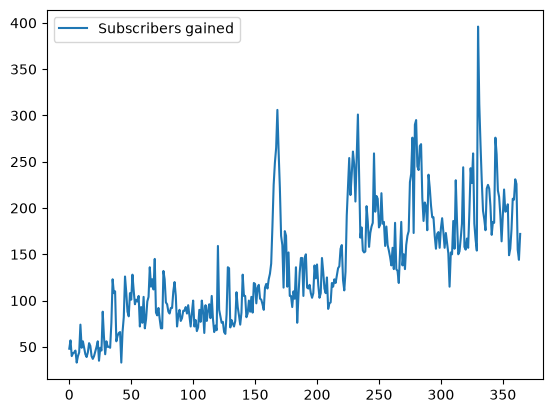

In [92]:
csv_subs.plot()

<Axes: xlabel='lead'>

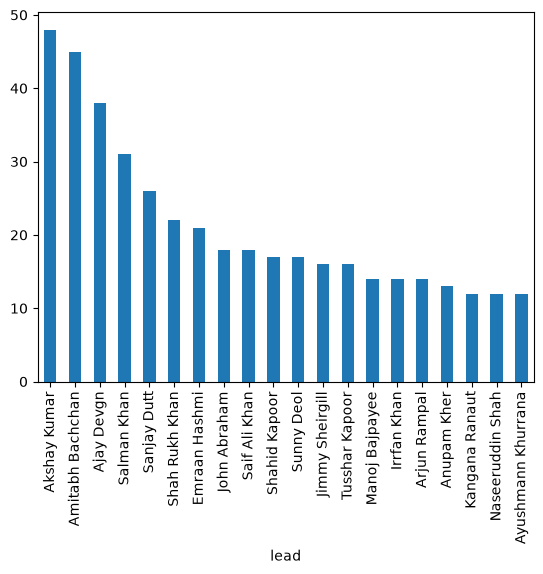

In [99]:
csv_movies.value_counts().head(20).plot(kind="bar")

<Axes: >

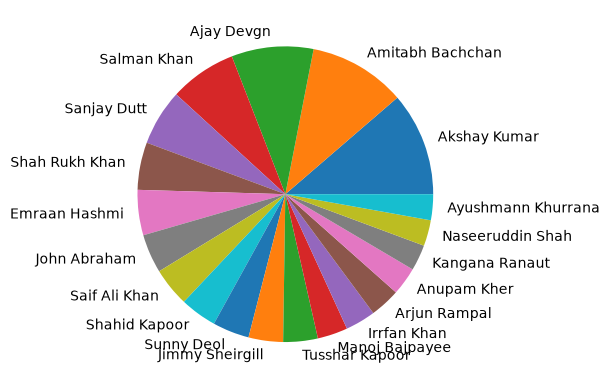

In [100]:
csv_movies.value_counts().head(20).plot(kind="pie")

## 🎯 Practice Tasks

🟢 **Easy:** Create a line plot of a simple numeric Series.

🟡 **Medium:** Create a Series with `np.nan` values. Fill them with `0`.

🔴 **Hard:** Use `.apply()` with a lambda function to categorize numbers: if > 50 return "High", else "Low".


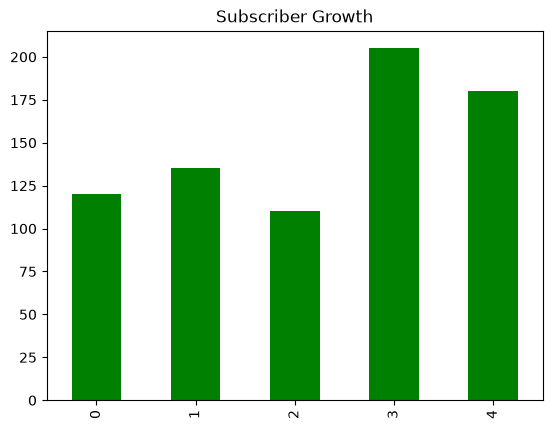


Filled NaNs with 0:
 0    10.0
1    20.0
2     0.0
3    40.0
4     0.0
dtype: float64

Apply custom function:
 0     100.0
1     400.0
3    1600.0
dtype: float64


In [ ]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
# Plotting
subs = pd.Series([120, 135, 110, 205, 180])
subs.plot(kind='bar', title="Subscriber Growth", color='green')
plt.show()

# Handling Missing Data
messy_data = pd.Series([10, 20, np.nan, 40, np.nan])
print("\nFilled NaNs with 0:\n", messy_data.fillna(0))

# Apply
print("\nApply custom function:\n", messy_data.dropna().apply(lambda x: x**2))


# Some Important Series Methods
### astype
### between
### clip
### drop_duplicates
### isnull
### dropna
### fillna
### isin
### apply
### copy

In [ ]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 7)
# ==========================================
# 🟢 Easy: Create a line plot of pd.Series([1, 4, 9, 16])
# YOUR CODE HERE:


# 🟡 Medium: Create a Series with NaNs, fill them with the mean of the Series.
# YOUR CODE HERE:


# 🔴 Hard: Use .apply() to return "Even" or "Odd" for a Series of numbers.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```

# ==========================================
# ✅ SOLUTIONS (Module 7)
# ==========================================
# 🟢 Easy
pd.Series([1, 4, 9, 16]).plot(kind='line')
plt.show()

# 🟡 Medium
s = pd.Series([10, 20, np.nan, 40])
print(s.fillna(s.mean()))

# 🔴 Hard
s = pd.Series([1, 2, 3, 4, 5])
print(s.apply(lambda x: "Even" if x % 2 == 0 else "Odd"))

```

</details>


# 🎉 Congratulations!
You have completed the **Pandas Series Masterclass**. 

### 🚀 Next Steps
Now that you have mastered the 1-Dimensional Series, you are ready to combine multiple Series side-by-side to create a **Pandas DataFrame** (a 2D table). 

*Keep practicing, and see you in the DataFrame module!*
